# Natural Language Processor

## Import Library

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import nltk
import re

from nltk.corpus import stopwords

from sklearn.datasets import fetch_20newsgroups

from sklearn.model_selection import train_test_split

from sklearn.feature_extraction.text import (
    CountVectorizer,
    TfidfVectorizer
)

from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

In [22]:
nltk.download("stopwords")

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\nguye\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [23]:
cartegories = [
    "rec.sport.hockey",
    "sci.space"
]

dataset = fetch_20newsgroups(
    subset="all",
    categories=cartegories,
    remove=("headers", "footers", "quotes")
)

In [24]:
df = pd.DataFrame({
    "text": dataset.data,
    "target": dataset.target
})

df.head(10)

,text,target
0,"\n\n\n\n\n\nWell, I guess I'm left wondering j...",1
1,"\n\n\n\n\tI think that you are incorrect, Roge...",0
2,"Forwarded from Neal Ausman, Galileo Mission Di...",1
3,\nPierre Turgeon of the Islanders,0
4,,0
5,u920496@daimi.aau.dk (Hans Erik Martino Hansen...,1
6,"\n""I hold that space cannot be curved, for the...",1
7,"\nClimbers regard 8000 metres and up as ""The D...",1
8,\nIf you've got a good propulsion system that'...,1
9,I haven't seen anyone post this so I will do t...,0


## Exploring the dataset

In [25]:
df.shape

(1986, 2)

In [26]:
df.target.value_counts()

target
0    999
1    987
Name: count, dtype: int64

## Text cleaning

In [27]:
# Create Stopwords list

stopwords = set(stopwords.words("english"))

In [28]:
def clean_text(text):

    # lower case
    text = text.lower()

    # remove number
    text = re.sub(r'\d+', '', text)

    # remove punctualation
    text = re.sub(r'[^\w\s]', '', text)

    # remove extra spaces
    text = text.strip()

    # remove stopword
    words = text.split()
    words = [
        word for word in words
        if word not in stopwords
    ]

    return " ".join(words)

In [29]:
# Apply cleanning

df["clean_text"] = df["text"].apply(clean_text)

In [30]:
vectorizer = CountVectorizer(
    max_features=5000
)

X = vectorizer.fit_transform(df["clean_text"])

In [31]:
y = df["target"]

## Train Test Split

In [32]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [33]:
nb = MultinomialNB()

nb.fit(X_train, y_train)

y_pred_nb = nb.predict(X_test)

In [34]:
print(classification_report(y_test, y_pred_nb))

              precision    recall  f1-score   support

           0       0.95      0.96      0.95       202
           1       0.96      0.94      0.95       196

    accuracy                           0.95       398
   macro avg       0.95      0.95      0.95       398
weighted avg       0.95      0.95      0.95       398



## Logistic Regression

In [35]:
lr = LogisticRegression(max_iter=1000)

lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

In [36]:
print(classification_report(y_test, y_pred_lr))

              precision    recall  f1-score   support

           0       0.96      0.92      0.94       202
           1       0.92      0.96      0.94       196

    accuracy                           0.94       398
   macro avg       0.94      0.94      0.94       398
weighted avg       0.94      0.94      0.94       398



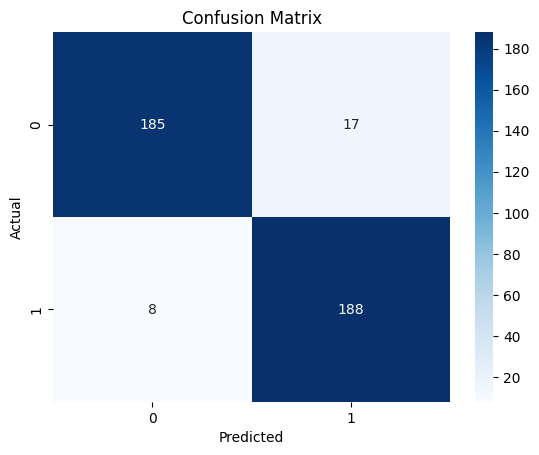

In [37]:
cm = confusion_matrix(y_test, y_pred_lr)

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [38]:
tfidf = TfidfVectorizer(
    max_features=5000
)

X_tfidf = tfidf.fit_transform(df["clean_text"])

In [39]:
X_train, X_test, y_train, y_test = train_test_split(
    X_tfidf,
    y,
    test_size=0.2,
    random_state=42
)

In [40]:
lr = LogisticRegression(max_iter=1000)

lr.fit(X_train, y_train)

y_pred = lr.predict(X_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.98      0.90      0.94       202
           1       0.91      0.98      0.94       196

    accuracy                           0.94       398
   macro avg       0.94      0.94      0.94       398
weighted avg       0.95      0.94      0.94       398

